<a href="https://colab.research.google.com/github/Maomi0906/Kravets-Maksym/blob/main/OSMnx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install osmnx -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.5 MB/s eta 0:00:00


🗺️  Načítám mapu okolí Vinohrad...
✅ Trasa nalezena! Délka: 462 metrů.
📊 Zobrazuji grafickou mapu...


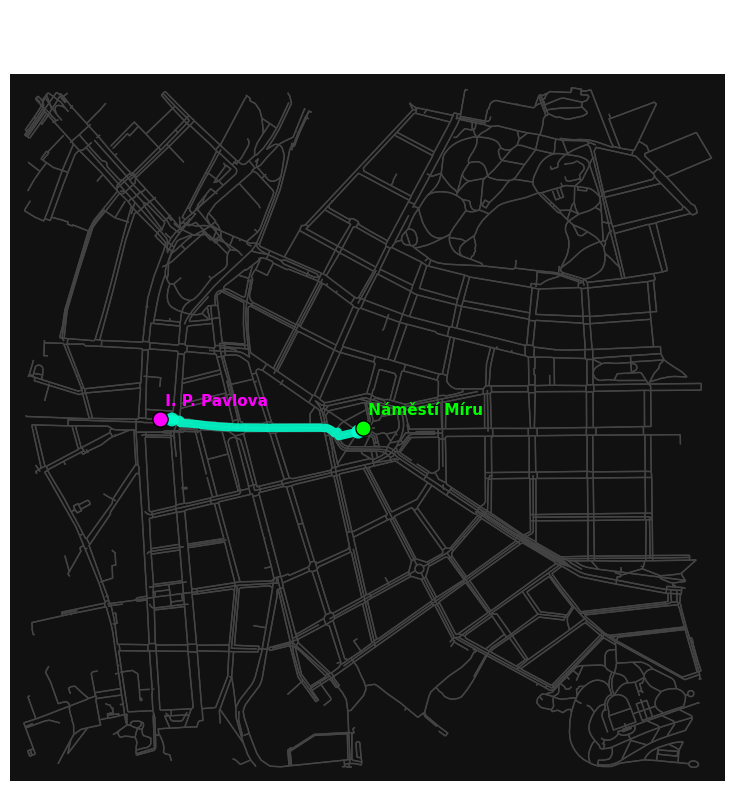

In [16]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt


START_GPS = (50.0754, 14.4364)
CIL_GPS = (50.0756, 14.4297)

print("🗺️  Načítám mapu okolí Vinohrad...")

G = ox.graph_from_point(START_GPS, dist=800, network_type="walk")


def bellman_ford(graf, start, cil):
    uzly = list(graf.nodes)
    hrany = []
    for u, v, k, d in graf.edges(data=True, keys=True):
        hrany.append((u, v, d.get("length", 1)))

    dist = {u: float("inf") for u in uzly}
    dist[start] = 0
    odkud = {u: None for u in uzly}

    for _ in range(len(uzly) - 1):
        zmenilo_se = False
        for u, v, vaha in hrany:
            if dist[u] + vaha < dist[v]:
                dist[v] = dist[u] + vaha
                odkud[v] = u
                zmenilo_se = True
        if not zmenilo_se:
            break

    cesta, uzel = [], cil
    while uzel is not None:
        cesta.append(uzel)
        uzel = odkud[uzel]
    cesta.reverse()
    return dist[cil], cesta


start_node = ox.nearest_nodes(G, X=START_GPS[1], Y=START_GPS[0])
cil_node   = ox.nearest_nodes(G, X=CIL_GPS[1],   Y=CIL_GPS[0])

vzdalenost, trasa = bellman_ford(G, start_node, cil_node)

print(f"✅ Trasa nalezena! Délka: {vzdalenost:.0f} metrů.")


fig, ax = ox.plot_graph_route(
    G, trasa,
    route_color="#00FFCC",
    route_linewidth=6,
    route_alpha=0.9,
    node_size=0,
    edge_color="#444444",
    bgcolor="#111111",
    show=False,
    close=False
)


ax.scatter(START_GPS[1], START_GPS[0], c='#00FF00', s=120, label='Mírák', zorder=5, edgecolors='black')
ax.scatter(CIL_GPS[1], CIL_GPS[0], c='#FF00FF', s=120, label='I.P.ák', zorder=5, edgecolors='black')


ax.text(START_GPS[1], START_GPS[0] + 0.0003, ' Náměstí Míru', color='#00FF00', fontsize=11, fontweight='bold')
ax.text(CIL_GPS[1], CIL_GPS[0] + 0.0003, ' I. P. Pavlova', color='#FF00FF', fontsize=11, fontweight='bold')

plt.title(f"Pěší trasa: Náměstí Míru ➔ I. P. Pavlova\n(Vzdálenost: cca {vzdalenost:.0f} m)",
          color='white', fontsize=14, pad=20)

plt.tight_layout()
print("📊 Zobrazuji grafickou mapu...")
plt.show()

🔍 Načítám mapové podklady pro Prahu 2...
✅ Výpočet dokončen: 462 metrů, cca 5 min 32 s.
🎨 Generuji finální mapu...
🚀 Hotovo! Otevírám okno s mapou.


/tmp/ipykernel_13914/2736665527.py:90: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13914/2736665527.py:90: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


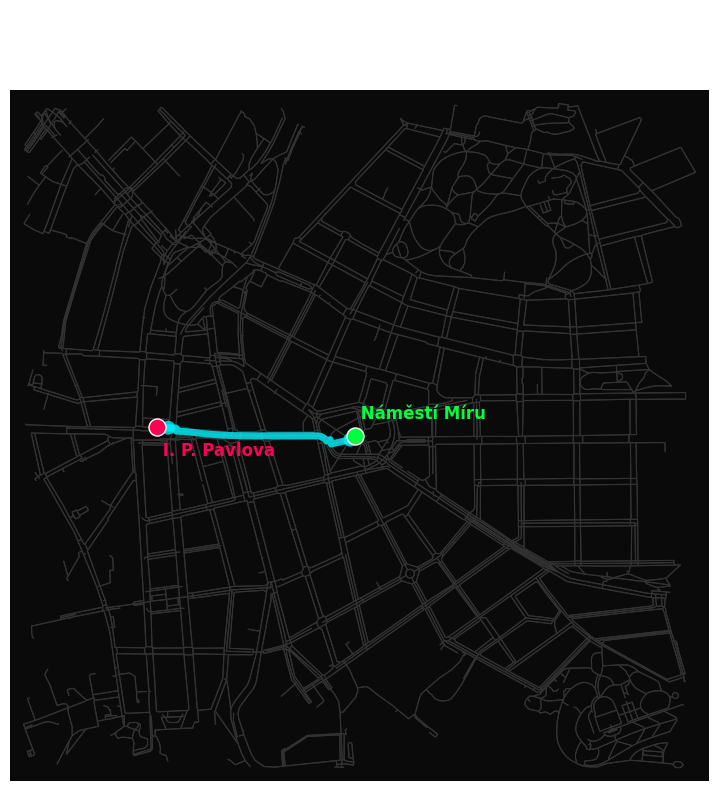

In [17]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt


START_GPS = (50.0754, 14.4364)
CIL_GPS = (50.0756, 14.4297)

print("🔍 Načítám mapové podklady pro Prahu 2...")

G = ox.graph_from_point(START_GPS, dist=800, network_type="walk")


def bellman_ford(graf, start, cil):
    uzly = list(graf.nodes)
    hrany = []

    for u, v, k, d in graf.edges(data=True, keys=True):
        hrany.append((u, v, d.get("length", 1)))


    dist = {u: float("inf") for u in uzly}
    dist[start] = 0
    odkud = {u: None for u in uzly}


    for _ in range(len(uzly) - 1):
        zmenilo_se = False
        for u, v, vaha in hrany:
            if dist[u] + vaha < dist[v]:
                dist[v] = dist[u] + vaha
                odkud[v] = u
                zmenilo_se = True
        if not zmenilo_se:
            break

    cesta, uzel = [], cil
    while uzel is not None:
        cesta.append(uzel)
        uzel = odkud[uzel]
    cesta.reverse()

    return dist[cil], cesta


start_node = ox.nearest_nodes(G, X=START_GPS[1], Y=START_GPS[0])
cil_node   = ox.nearest_nodes(G, X=CIL_GPS[1],   Y=CIL_GPS[0])


vzdalenost, trasa = bellman_ford(G, start_node, cil_node)


rychlost_chuze = 1.39
cas_sekundy = vzdalenost / rychlost_chuze
minuty = int(cas_sekundy // 60)
sekundy = int(cas_sekundy % 60)

print(f"✅ Výpočet dokončen: {vzdalenost:.0f} metrů, cca {minuty} min {sekundy} s.")


print("🎨 Generuji finální mapu...")

fig, ax = ox.plot_graph_route(
    G, trasa,
    route_color="#00f2ff",
    route_linewidth=5,
    route_alpha=0.8,
    node_size=0,
    edge_color="#333333",
    edge_linewidth=0.8,
    bgcolor="#0a0a0a",
    show=False,
    close=False
)


ax.scatter(START_GPS[1], START_GPS[0], c='#00ff41', s=150, zorder=5, edgecolors='white', label='Start')
ax.scatter(CIL_GPS[1], CIL_GPS[0], c='#ff0055', s=150, zorder=5, edgecolors='white', label='Cíl')


ax.text(START_GPS[1], START_GPS[0] + 0.0004, ' Náměstí Míru', color='#00ff41', fontsize=12, fontweight='bold')
ax.text(CIL_GPS[1], CIL_GPS[0] - 0.0006, ' I. P. Pavlova', color='#ff0055', fontsize=12, fontweight='bold')


plt.title(f"PĚŠÍ TRASA VINOHRADY\n"
          f"📏 {vzdalenost:.0f} m  |  ⏱️ {minuty} min {sekundy} s",
          color='white', fontsize=16, fontweight='light', pad=30)


plt.tight_layout()

print("🚀 Hotovo! Otevírám okno s mapou.")
plt.show()